### 코드 설명

1. **CIFAR-100 사전학습:**  
   CIFAR-100 데이터셋을 사용해 `SimpleCNN` 모델을 5 에폭 동안 학습한 후, 가중치를 저장합니다.

2. **MNIST 데이터 전처리:**  
   MNIST 이미지를 32×32, 3채널로 변환하여 CIFAR-100 모델에 맞게 전처리합니다.

3. **MNIST Full Fine-tuning:**  
   - CIFAR-100 사전학습된 feature extractor를 불러온 후, classifier의 마지막 레이어를 `Linear(256, 10)`으로 교체합니다.  
   - 전체 네트워크를 업데이트하며 (전체 파라미터 학습), 작은 학습률(1e-4)을 사용합니다.  
   - 에폭별 train/validation loss와 accuracy를 각각 `ft_train_losses`, `ft_train_accs`, `ft_val_losses`, `ft_val_accs`에 저장합니다.

4. **MNIST Feature Extraction:**  
   - 동일하게 사전학습된 feature extractor를 로드한 후, feature extractor는 고정시키고 classifier만 재정의하여 업데이트합니다.  
   - classifier만 업데이트합니다. 학습률은 1e-3을 사용합니다.  
   - 에폭별 metric은 `fe_train_losses`, `fe_train_accs`, `fe_val_losses`, `fe_val_accs`에 저장합니다.

5. **성능 비교 Plot:**  
   - 두 실험의 Accuracy와 Loss를 각각 plot하여 비교합니다.

이 코드를 실행하면 두 접근법의 에폭별 성능 변화를 비교할 수 있는 plot이 생성됩니다.

# 사전 함수

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:
def imshow(img, title = None, cmap = None):
    npimg = img.numpy()
    if npimg.shape[0] == 1: # 이미지가 흑백인 경우
        npimg = npimg[0]    # (1, 28, 28) => (28, 28)

    else:
        npimg = np.transpose(npimg, (1, 2, 0)) # 토치 형태로 뽑으면 c, h, w 이렇게 나오는데 => matplot으로 보려면 h w c 순서로 바꾼다

    plt.imshow(npimg, cmap = cmap)

    if title:
        plt.title(title)

    plt.axis('off')

In [ ]:
def print_dataset_info(name, train_set, test_set):
    sample_img, sample_label = train_set[0]
    print(f"======={name}=======")
    print('train 샘플 개수: ', len(train_set))
    print('test 샘플 개수: ', len(test_set))
    print('샘플 이미지 텐서 shape: ', sample_img.shape)
    if hasattr(train_set, 'classes'): # train_set 안에 classes 항목이 존재하면
         print("클래스 개수: ", len(train_set.classes))
         print("클래스 이름: ", train_set.classes)
    print()

In [ ]:
def visualize_one_per_category(dataset, dataset_name = "Dataset", cmap = None):
    """
    데이터셋의 각 카테고리(클래스)별로 하나의 대표 이미지를 시각화하는 함수

    Parameters:
    -----------
    dataset : torch.utils.data.Dataset
        시각화할 데이터셋 객체. 일반적으로 torchvision.datasets의 서브클래스임
        __getitem__ 메서드가 (이미지, 레이블) 튜플을 반환해야 함
        classes 속성(클래스 이름 목록)과 targets/train_labels 속성(레이블 배열)이 있어야 함

    dataset_name : str, optional
        시각화 결과물에 표시할 데이터셋 이름 (기본값: "Dataset")

    cmap : str or matplotlib Colormap, optional
        흑백 이미지에 사용할 컬러맵 (기본값: None, matplotlib 기본 컬러맵 사용)
    """

    # 1. 샘플 수집을 위한 빈 딕셔너리 생성
    # 이 딕셔너리는 각 클래스(카테고리)별로 하나의 대표 이미지를 저장하는 용도로 사용됩니다
    # 키(key)는 클래스 레이블(정수), 값(value)은 해당 클래스의 첫 번째 이미지 텐서입니다
    # 예: {0: tensor(...), 1: tensor(...), 2: tensor(...), ...}
    samples = {}

    # 2. 데이터셋에서 레이블 정보 추출
    # torchvision 데이터셋은 일반적으로 두 가지 방식으로 레이블 정보를 저장합니다:
    # - 최신 버전: .targets 속성 (모든 샘플의 레이블을 포함하는 리스트 또는 배열)
    # - 구 버전: .train_labels 속성 (동일한 목적)
    # hasattr() 함수는 객체에 특정 속성이 있는지 확인합니다
    # 이 코드는 데이터셋에 'targets' 속성이 있으면 그것을 사용하고, 없으면 'train_labels'를 사용합니다
    # 이 정보는 실제로 이 함수에서 직접 사용되지는 않지만, 데이터셋 구조 이해를 위해 참고용으로 추출합니다
    targets = dataset.targets if hasattr(dataset, 'targets') else dataset.train_labels

    # 3. 데이터셋을 순회하며 각 클래스별 첫 번째 이미지 수집
    # 데이터셋의 모든 샘플을 처음부터 끝까지 순차적으로 검사합니다
    # len(dataset)은 데이터셋에 포함된 총 샘플 수를 반환합니다
    for idx in range(len(dataset)):
        # dataset[idx]는 데이터셋의 __getitem__ 메서드를 호출하여
        # 인덱스 idx에 해당하는 데이터 샘플을 반환합니다
        # 일반적으로 (이미지, 레이블) 형태의 튜플로 반환됩니다
        # 이미지는 PIL.Image 객체 또는 PyTorch Tensor일 수 있습니다
        # 레이블은 정수(int) 또는 PyTorch Tensor일 수 있습니다
        img, label = dataset[idx]

        # 3.1 레이블 형식을 통일합니다 (Tensor → 정수)
        # 레이블이 PyTorch Tensor인 경우, item() 메서드를 사용하여 Python 스칼라 값으로 변환합니다
        # 이는 딕셔너리 키로 사용하기 위함입니다 (Tensor 객체는 딕셔너리 키로 사용할 수 없습니다)
        # 예: tensor(3) → 3
        if torch.is_tensor(label):
            label = label.item()

        # 3.2 새로운 클래스를 발견하면 해당 이미지를 저장합니다
        # 현재 레이블이 samples 딕셔너리에 아직 존재하지 않는지 확인합니다
        # 이 조건문은 각 클래스별로 첫 번째로 발견되는 이미지만 저장하기 위한 로직입니다
        if label not in samples:
            # 딕셔너리에 새로운 키-값 쌍을 추가합니다
            # 키: 현재 레이블, 값: 현재 이미지
            samples[label] = img

        # 3.3 종료 조건을 확인합니다
        # 수집된 샘플 수가 데이터셋의 총 클래스 수와 같거나 큰 경우 반복을 중단합니다
        # dataset.classes는 데이터셋의 클래스 이름 목록입니다 (예: CIFAR-10의 경우 ['airplane', 'automobile', ...])
        # len(dataset.classes)는 총 클래스 개수를 의미합니다
        # 모든 클래스의 대표 이미지를 수집했으면 더 이상 반복할 필요가 없으므로 조기 종료합니다
        if len(samples) >= len(dataset.classes):
            break  # 반복문을 탈출합니다

    # 4. 시각화를 위한 정보 수집
    # 데이터셋의 총 클래스 개수를 계산하여 변수에 저장합니다
    # 이 값은 서브플롯 그리드의 크기를 결정하는 데 사용됩니다
    n_categories = len(dataset.classes)
    # 클래스 개수를 포맷 문자열을 사용하여 출력합니다 (디버깅 및 정보 제공 목적)
    print(f'{dataset_name} 카테고리 개수: {n_categories}')

    # 5. 서브플롯 그리드의 행과 열 개수를 계산합니다
    # 열(cols) 개수 결정:
    # - 클래스가 10개 이상이면 10열로 고정합니다 (가로로 너무 길어지는 것을 방지하기 위함)
    # - 10개 미만이면 실제 클래스 수만큼 설정합니다
    cols = 10 if n_categories >= 10 else n_categories
    # 행(rows) 개수 계산:
    # - 총 클래스 수를 열 개수로 나눈 후 math.ceil 함수로 올림 처리합니다
    # - 예: 15개 클래스, 10열 → 15/10 = 1.5 → ceil(1.5) = 2행
    rows = math.ceil(n_categories / cols)

    # 6. matplotlib를 사용하여 서브플롯 그리드를 생성합니다
    # plt.subplots() 함수는 지정된 행과 열 수에 맞는 서브플롯 배열을 생성합니다
    # 반환값:
    # - fig: 전체 그림 객체 (Figure)
    # - axes: 서브플롯 축 객체의 배열 (numpy.ndarray 또는 단일 Axes 객체)
    # figsize: 전체 그림 크기를 설정합니다 (가로: cols×2 인치, 세로: rows×2 인치)
    # 2인치를 곱하는 것은 각 서브플롯의 크기를 적절하게 조정하기 위한 경험적 값입니다
    fig, axes = plt.subplots(rows, cols, figsize = (cols * 2, rows * 2))

    # 7. 서브플롯 축 객체를 처리합니다
    # 서브플롯이 여러 개인 경우와 단일 서브플롯인 경우 다른 방식으로 처리해야 합니다
    if rows * cols > 1:
        # 다중 서브플롯인 경우: axes 배열을 1차원으로 평탄화(flatten)하여 인덱싱을 쉽게 만듭니다
        # 예: 2×5 격자 → 10개 요소의 1차원 배열
        axes = axes.flatten()
    else:
        # 단일 서브플롯인 경우: axes를 단일 요소 리스트로 래핑하여 일관된 처리가 가능하도록 합니다
        axes = [axes]

    # 8. 각 서브플롯에 이미지와 제목을 추가합니다
    # sorted(samples.keys()): 레이블 값을 기준으로 오름차순 정렬하여 순회합니다
    # enumerate() 함수는 인덱스(i)와 값(label)을 동시에 반환합니다
    for i, label in enumerate(sorted(samples.keys())):
        # 8.1 현재 처리할 서브플롯 축을 선택합니다
        ax = axes[i]  # i번째 서브플롯 축 선택

        # 8.2 현재 레이블에 해당하는 이미지를 가져옵니다
        img = samples[label]  # 딕셔너리에서 레이블로 이미지를 조회합니다

        # 8.3 이미지 데이터 형식을 변환합니다
        # PyTorch Tensor를 NumPy 배열로 변환합니다 (matplotlib는 NumPy 배열을 기반으로 작동합니다)
        npimg = img.numpy()

        # 8.4 이미지 채널 수에 따라 다른 방식으로 처리합니다
        # 흑백 이미지인 경우: 채널 차원이 1입니다 (shape: [1, height, width])
        if npimg.shape[0] == 1:
            # 흑백 이미지의 경우 첫 번째 차원을 제거하여 [height, width] 형태로 변환합니다
            npimg = npimg[0]
            # imshow 함수에 흑백 전용 컬러맵(cmap)을 적용합니다
            # cmap 매개변수가 None이면 matplotlib의 기본 컬러맵을 사용합니다
            ax.imshow(npimg, cmap = cmap)
        else:
            # 컬러 이미지인 경우: 채널 차원을 조정해야 합니다
            # PyTorch는 일반적으로 [channels, height, width] 형식을 사용합니다
            # matplotlib는 [height, width, channels] 형식을 기대합니다
            # np.transpose를 사용하여 차원 순서를 변경합니다
            npimg = np.transpose(npimg, (1, 2, 0))
            # 컬러맵 없이 이미지를 표시합니다 (컬러 이미지는 자체 색상 정보를 포함합니다)
            ax.imshow(npimg)

        # 8.5 서브플롯 제목을 설정합니다
        # 데이터셋에 클래스 이름 목록이 있는지 확인합니다
        if hasattr(dataset, 'classes'):
            # classes 속성이 있으면 해당 레이블 인덱스의 클래스 이름을 사용합니다
            class_name = dataset.classes[label]
        else:
            # classes 속성이 없으면 레이블 값을 문자열로 변환하여 사용합니다
            class_name = str(label)
        # set_title() 메서드로 서브플롯 제목을 설정합니다
        # fontsize=8으로 작은 글꼴 크기를 설정합니다 (공간을 절약하기 위함)
        ax.set_title(class_name, fontsize = 8)

        # 8.6 축 요소를 숨깁니다
        # axis('off')는 축의 눈금, 레이블, 테두리 등을 모두 숨겨 이미지에만 집중할 수 있게 합니다
        ax.axis('off')

    # 9. 사용되지 않은 서브플롯을 숨깁니다
    # i는 마지막으로 처리된 서브플롯의 인덱스입니다 (0-based)
    # range(i + 1, len(axes)): 사용되지 않은 서브플롯의 인덱스 범위입니다
    for j in range(i + 1, len(axes)):
        # 사용되지 않은 서브플롯도 axis('off')로 숨깁니다
        axes[j].axis('off')

    # 10. 전체 그림에 제목을 추가합니다
    # plt.suptitle()은 모든 서브플롯을 아우르는 전체 제목을 설정합니다
    # fontsize=15로 제목 글꼴 크기를 설정합니다
    plt.suptitle(f"{dataset_name} - 1 sample per category", fontsize = 15)

    # 11. 레이아웃을 자동으로 조정합니다
    # tight_layout()은 서브플롯 간 간격, 레이블, 제목 등을 자동으로 조정하여
    # 요소들이 겹치지 않도록 최적의 레이아웃을 계산합니다
    plt.tight_layout()

    # 12. 시각화 결과를 표시합니다
    # plt.show()는 현재까지 구성된 그림을 실제로 화면에 렌더링하여 표시합니다
    # Jupyter Notebook에서는 셀 출력에 이미지가 표시됩니다
    # 스크립트 실행에서는 별도의 창이 열려 이미지가 표시됩니다
    plt.show()

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

cifar_train = torchvision.datasets.CIFAR100(root='data', train=True, download=True, transform=transform)
cifar_test =  torchvision.datasets.CIFAR100(root='data', train=False, download=True, transform=transform)

mnist_train = torchvision.datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test =  torchvision.datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [ ]:
print_dataset_info('CIFAR100', cifar_train, cifar_test)
print_dataset_info('MNIST', mnist_train, mnist_test)

=======CIFAR100=======
train 샘플 개수:  50000
test 샘플 개수:  10000
샘플 이미지 텐서 shape:  torch.Size([3, 32, 32])
클래스 개수:  100
클래스 이름:  ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', '

CIFAR100 카테고리 개수: 100


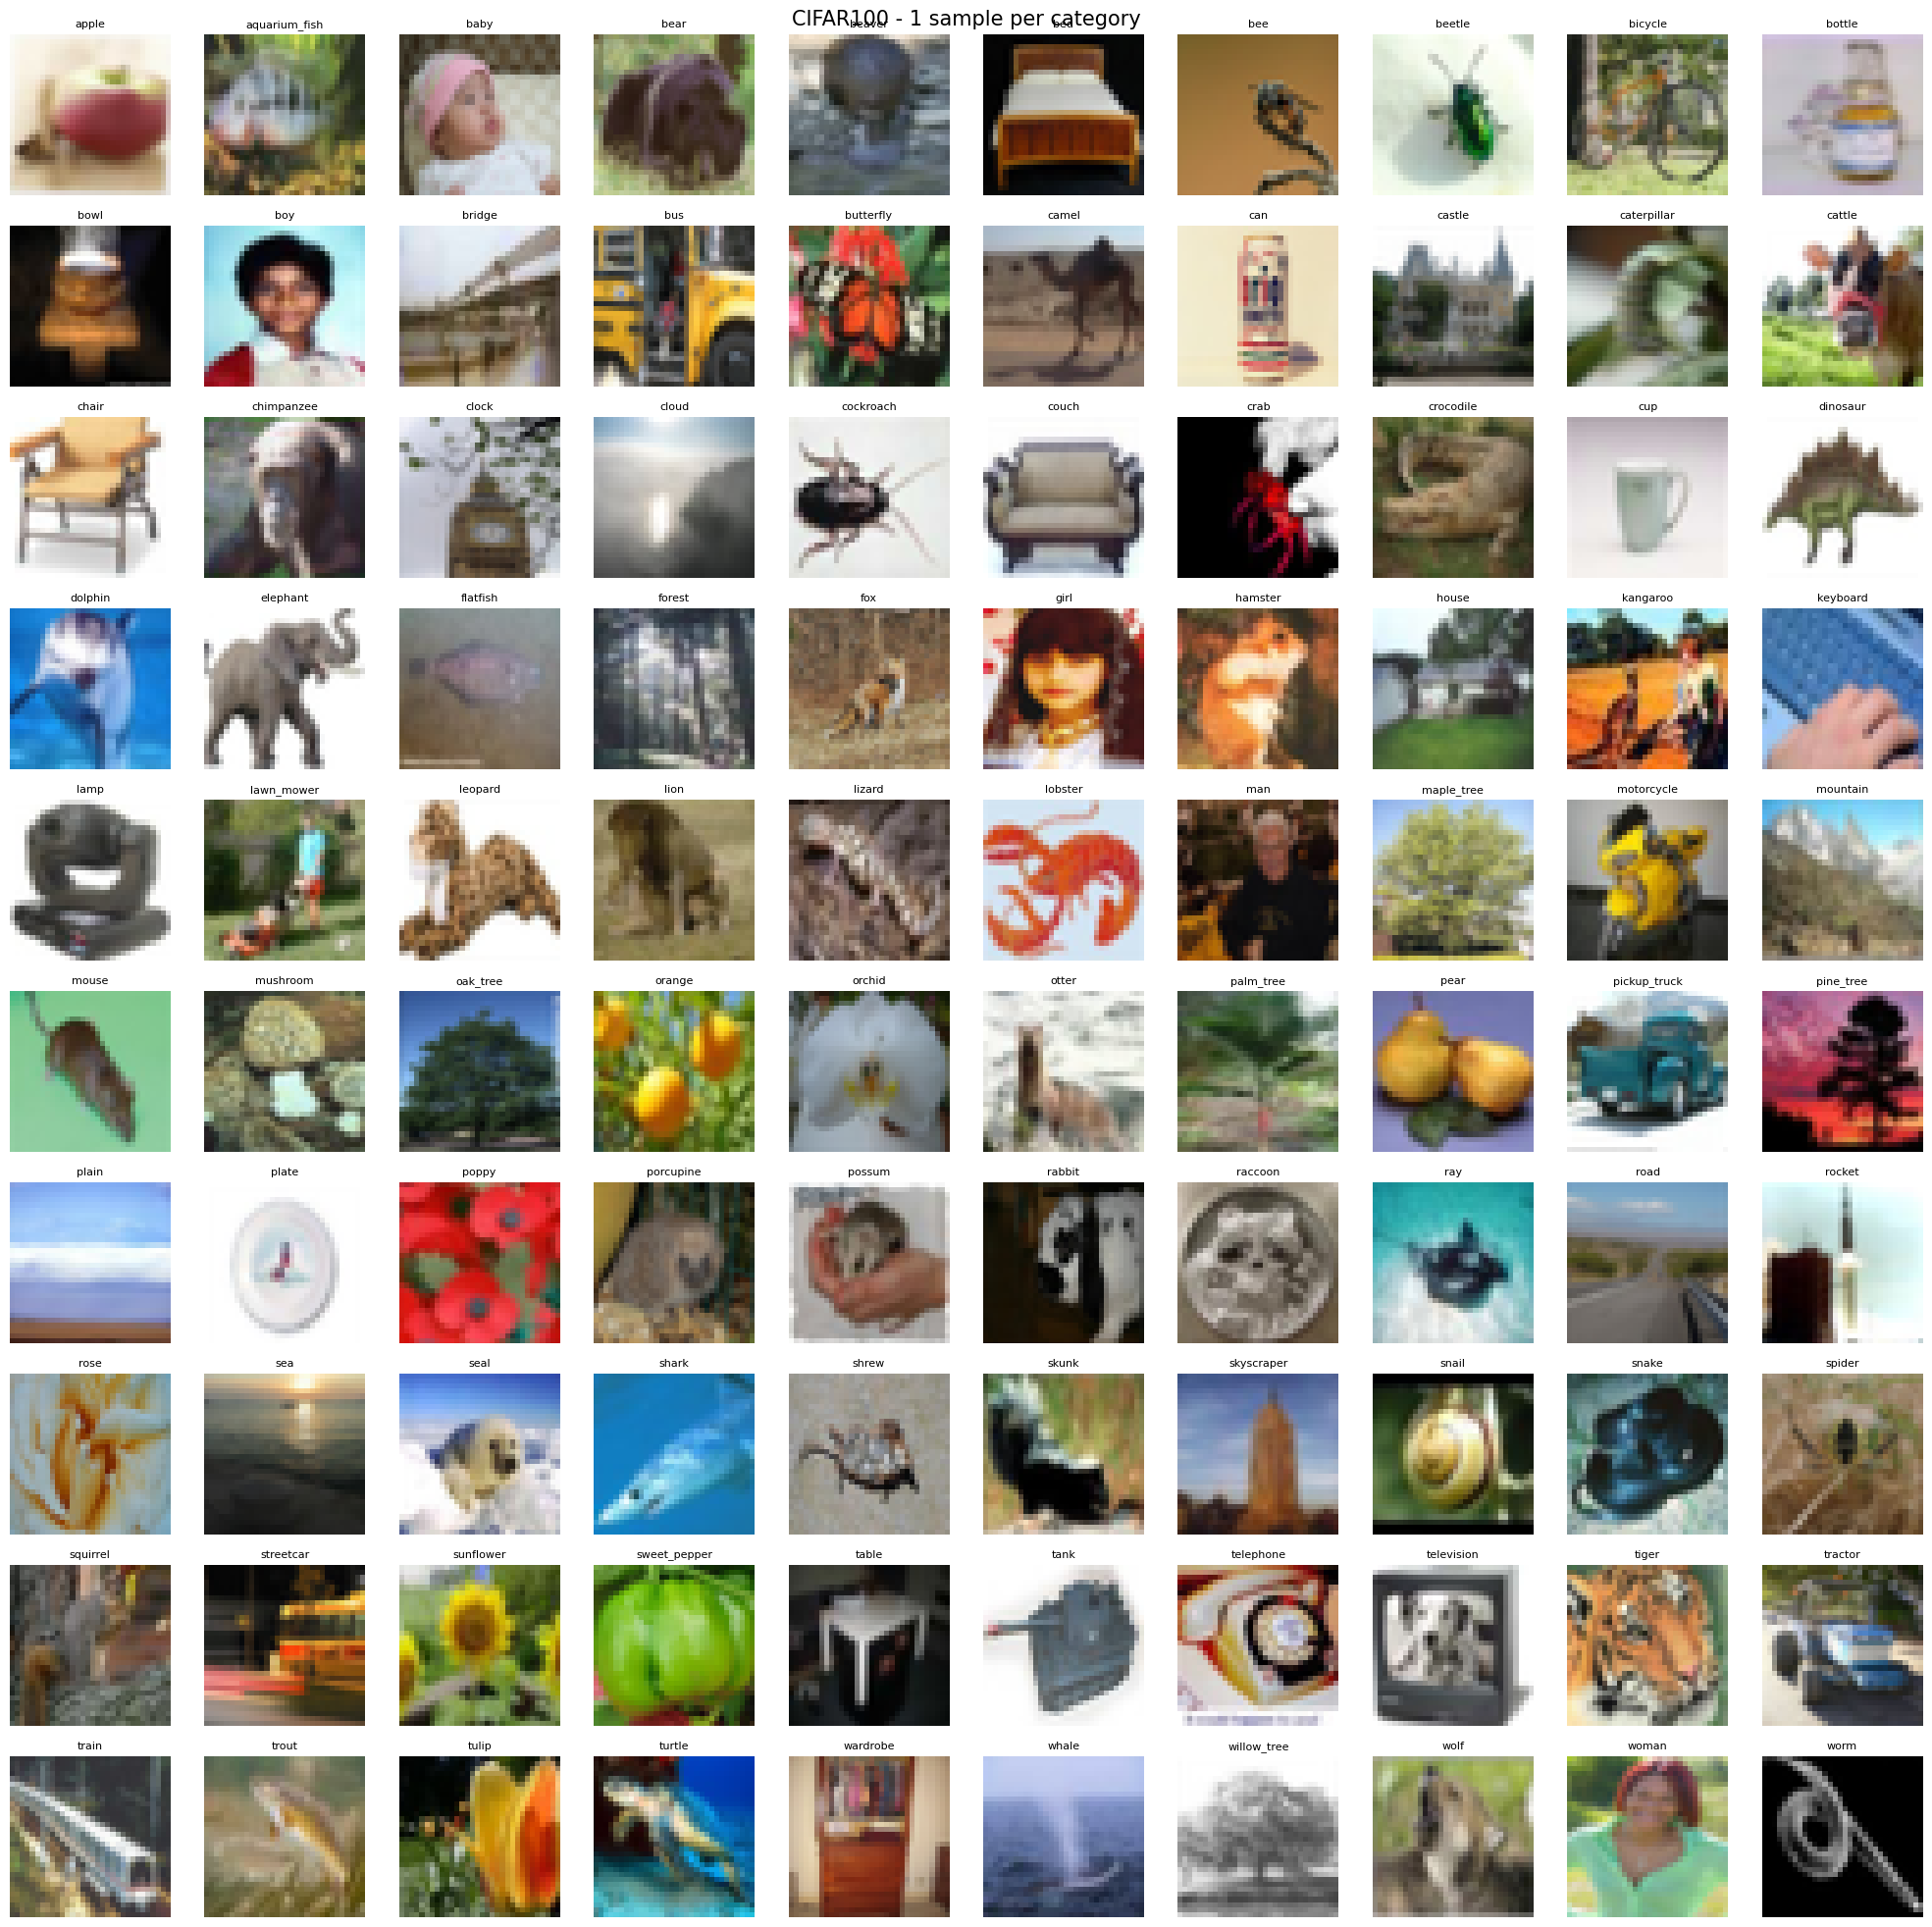

MNIST 카테고리 개수: 10


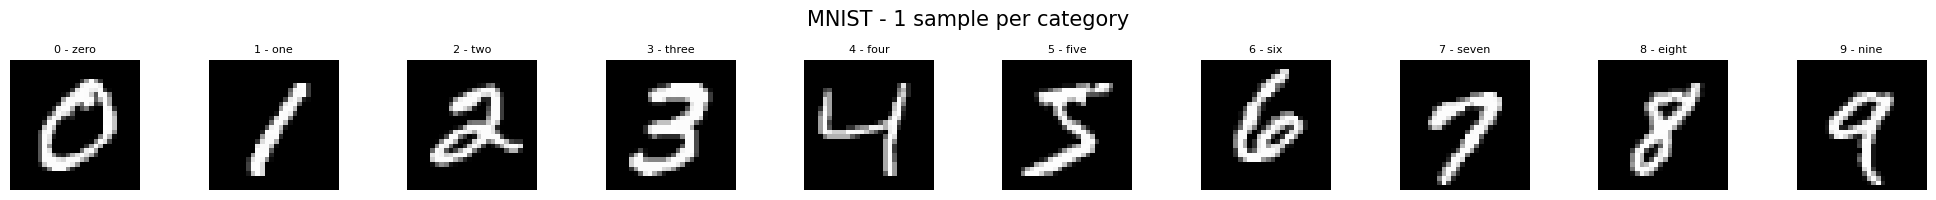

In [ ]:
visualize_one_per_category(cifar_train, dataset_name = "CIFAR100")
visualize_one_per_category(mnist_train, dataset_name = "MNIST", cmap = 'gray')

# 1ch => 3ch

In [ ]:
from PIL import Image

gray_img_array = mnist_train.data[0].numpy()
gray_img_pil = Image.fromarray(gray_img_array, mode="L")

transform_to3 = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])
img_method1 = transform_to3(gray_img_pil)
print(img_method1.shape) # 이방법이 학습할 때는 더 유용하다

img_method2 = transforms.ToTensor()(gray_img_pil.convert('RGB'))
print(img_method2.shape)

torch.Size([3, 28, 28])
torch.Size([3, 28, 28])


/tmp/ipython-input-2909343529.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  gray_img_pil = Image.fromarray(gray_img_array, mode="L")


In [ ]:
diff = torch.abs(img_method1-img_method2)
max_diff = diff.max().item()
mean_diff = diff.mean().item()

print(max_diff, mean_diff)

0.0 0.0


# 모델 설계

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

from tqdm import tqdm # 진행상황을 표시하기 위한 라이브러리
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# nn.Module을 상속받는 SimpleCNN 클래스 정의
# 이 클래스는 합성곱 신경망(CNN) 아키텍처를 구현합니다
class SimpleCNN(nn.Module):
    # 클래스 생성자 (초기화 메서드)
    def __init__(self):
        # 부모 클래스(nn.Module)의 생성자 호출
        # 이는 PyTorch 모델의 기본 기능을 상속받기 위해 필요합니다
        super().__init__()

        # 특징 추출기를 구성하는 Sequential 모듈 정의
        # Sequential은 여러 계층을 순차적으로 연결하는 컨테이너입니다
        self.features = nn.Sequential(
            # 첫 번째 합성곱 계층 (Convolutional Layer)
            # 입력 채널: 3 (RGB 컬러 이미지), 출력 채널: 32, 커널 크기: 3x3
            # stride: 1 (커널 이동 간격), padding: 1 (입력 주변에 0으로 채움)
            # 입력 크기: [batch_size, 3, 32, 32] → 출력 크기: [batch_size, 32, 32, 32]
            nn.Conv2d(3, 32, 3, 1, 1),   # 3 => 32

            # 배치 정규화 계층 (Batch Normalization)
            # 특징 맵의 출력을 정규화하여 학습 안정성을 높임
            # 입력 채널 수: 32
            nn.BatchNorm2d(32),

            # ReLU 활성화 함수 (Rectified Linear Unit)
            # 음수 값을 0으로 만들고 양수 값은 그대로 통과시킴
            # 비선형성을 추가하여 모델의 표현력을 높임
            nn.ReLU(),

            # 최대 풀링 계층 (Max Pooling)
            # 커널 크기: 2x2, stride: 2 (기본값)
            # 특징 맵의 공간적 크기를 절반으로 축소하여 계산량 감소 및 과적합 방지
            # 출력 크기: [batch_size, 32, 16, 16] (32 x 32 => 16 x 16)
            nn.MaxPool2d(2),             # 32 x 32 => 16 x 16

            # 두 번째 합성곱 계층
            # 입력 채널: 32, 출력 채널: 64, 커널 크기: 3x3
            # stride: 1, padding: 1
            # 출력 크기: [batch_size, 64, 16, 16]
            nn.Conv2d(32, 64, 3, 1, 1),  # 32 => 64

            # 배치 정규화 계층 (입력 채널 수: 64)
            nn.BatchNorm2d(64),

            # ReLU 활성화 함수
            nn.ReLU(),

            # 최대 풀링 계층
            # 출력 크기: [batch_size, 64, 8, 8] (16 x 16 => 8 x 8)
            nn.MaxPool2d(2),             # 16 x 16 => 8 x 8

            # 세 번째 합성곱 계층
            # 입력 채널: 64, 출력 채널: 128, 커널 크기: 3x3
            # stride: 1, padding: 1
            # 출력 크기: [batch_size, 128, 8, 8]
            nn.Conv2d(64, 128, 3, 1, 1), # 64 => 128

            # 배치 정규화 계층 (입력 채널 수: 128)
            nn.BatchNorm2d(128),

            # ReLU 활성화 함수
            nn.ReLU(),

            # 최대 풀링 계층
            # 출력 크기: [batch_size, 128, 4, 4] (8 x 8 => 4 x 4)
            nn.MaxPool2d(2)              # 8 x 8 => 4 x 4
            )

        # 분류기를 구성하는 Sequential 모듈 정의
        # 전결합층(Fully Connected Layers)을 사용하여 최종 분류 수행
        self.classifier = nn.Sequential(
            # 첫 번째 전결합 계층
            # 입력 특징 수: 128 * 4 * 4 (마지막 합성곱 계층의 출력을 flatten한 크기)
            # 출력 특징 수: 256
            nn.Linear(128 * 4 * 4, 256),

            # ReLU 활성화 함수
            nn.ReLU(),

            # 드롭아웃 계층 (Dropout)
            # 과적합 방지를 위해 학습 시 50%의 뉴런을 무작위로 비활성화
            # 평가 모드에서는 모든 뉴런이 활성화됨
            # 평가 모드에서는 모든 뉴런이 활성화됨
            nn.Dropout(0.5),

            # 두 번째 전결합 계층 (출력 계층)
            # 입력 특징 수: 256, 출력 특징 수: 100
            # CIFAR-100 데이터셋의 클래스가 100개이기 때문
            # MNIST 데이터셋을 사용할 경우 10으로 변경해야 함
            nn.Linear(256, 100) # CIFAR100의 클래스가 100개이기 때문
            # => nn.Linear(256, 10) 이러면 MNIST에서 동작
        )

    # 순전파(forward) 메서드 정의
    # 모델이 입력 데이터를 받아 출력을 계산하는 과정
    def forward(self, x):
        # 특징 추출기를 통과하여 특징 맵 계산
        x = self.features(x)

        # 특징 맵을 flatten하여 1D 벡터로 변환
        # x.size(0)은 배치 크기를 의미하며, -1은 나머지 모든 차원을 flatten하도록 지정
        # [batch_size, 128, 4, 4] → [batch_size, 128 * 4 * 4]
        x = x.view(x.size(0), -1)

        # 분류기를 통과하여 최종 출력 계산
        x = self.classifier(x)

        # 최종 출력 반환 (크기: [batch_size, 100])
        return x

# 학습/검증 함수

In [ ]:
# 이걸 그냥 함수로 만들었다

def train_epoch(model, dataloader, loss_fn, opt):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, leave=False, desc="Train"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        opt.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, dim=1)
        # preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# 이거도 마찬가지로 그냥 함수로 만들었다

def validate_epoch(model, dataloader, loss_fn):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, leave=False, desc="Validataion"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# CIFAR100 전처리
transform_cifar = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408],
                         std=[0.2675, 0.2565, 0.2761])
])

In [ ]:
from random import shuffle
cifar_full = torchvision.datasets.CIFAR100(root='data',
                                           train=True,
                                           download=True,
                                           transform=transform_cifar)

train_size = int(0.9*len(cifar_full))
val_size = len(cifar_full) - train_size

cifar_train, cifar_val = random_split(cifar_full, [train_size, val_size])
cifar_train_loader = DataLoader(cifar_train,
                                batch_size=128,
                                shuffle=True,
                                drop_last=True,
                                num_workers=2)
cifar_val_loader = DataLoader(cifar_val,
                              batch_size=128,
                              shuffle=False,
                              num_workers=2)

In [ ]:
# 모델 초기화, 손실함수, 옵티마이저

model_cifar = SimpleCNN().to(device)
loss_fn = nn.CrossEntropyLoss() # 내부에서 softmax를 적용해서 계산한다
optim_cifar = optim.Adam(model_cifar.parameters(), lr = 0.001)

In [ ]:
# 모델 학습
# 이거 자체도 함수로 만들 수 있다

num_epochs = 5
for epoch in range(num_epochs):
    print(f'\n[Epoch {epoch+1}/{num_epochs}]')
    train_loss, train_acc = train_epoch(model_cifar, cifar_train_loader, loss_fn, optim_cifar)
    val_loss, val_acc = validate_epoch(model_cifar, cifar_val_loader, loss_fn)
    print(f"Train Loss: {train_loss:.4} // Train Acc: {train_acc:.4}")
    print(f"Train Loss: {train_loss:.4} // Val Acc: {train_acc:.4}")


[Epoch 1/5]


Train Loss: 4.026 // Train Acc: 0.08082
Train Loss: 4.026 // Val Acc: 0.08082

[Epoch 2/5]


Train Loss: 3.503 // Train Acc: 0.1494
Train Loss: 3.503 // Val Acc: 0.1494

[Epoch 3/5]


Train Loss: 3.27 // Train Acc: 0.1905
Train Loss: 3.27 // Val Acc: 0.1905

[Epoch 4/5]


Train Loss: 3.127 // Train Acc: 0.2124
Train Loss: 3.127 // Val Acc: 0.2124

[Epoch 5/5]


Train Loss: 3.011 // Train Acc: 0.2321
Train Loss: 3.011 // Val Acc: 0.2321


In [ ]:
os.makedirs('models', exist_ok = True)
torch.save(model_cifar.state_dict(), 'models/model_cifar100.pth')

In [ ]:
print(model_cifar.classifier)

Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=100, bias=True)
)


In [ ]:
print(model_cifar.classifier[3])

Linear(in_features=256, out_features=100, bias=True)


In [ ]:
print(model_cifar.features)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [ ]:
print(model_cifar.features[3])

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)


In [ ]:
transform_mnist = transforms.Compose([
    transforms.Resize(32),
    transforms.Grayscale(num_output_channels = 3),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [0.5, 0.5, 0.5])
])

In [ ]:
mnist_full = torchvision.datasets.MNIST(root = 'data',
                                        train = True,
                                        download = True,
                                        transform = transform_mnist)

mnist_train_size = int(0.9 * len(mnist_full))
mnist_val_size = len(mnist_full) - mnist_train_size

mnist_train, mnist_val = random_split(mnist_full, [mnist_train_size, mnist_val_size])

mnist_train_loader = DataLoader(mnist_train,
                                batch_size = 128,
                                shuffle = True,
                                drop_last = True,
                                num_workers = 2)
mnist_val_loader = DataLoader(mnist_train,
                              batch_size = 128,
                              shuffle = False,
                              num_workers = 2)

In [ ]:
# Fine-Tuning
model_mnist_ft = SimpleCNN().to(device)

model_cifar_dict = torch.load('models/model_cifar100.pth', map_location = device)

model_cifar_dict

OrderedDict([('features.0.weight',
              tensor([[[[-0.0358,  0.1860,  0.1812],
                        [ 0.0623,  0.0505,  0.1843],
                        [ 0.0214, -0.0047, -0.0267]],
              
                       [[ 0.0819,  0.1799,  0.1485],
                        [ 0.0518,  0.0173,  0.1437],
                        [-0.0143, -0.0091,  0.0354]],
              
                       [[ 0.0800, -0.0170,  0.1823],
                        [-0.1423, -0.0384, -0.0690],
                        [-0.2423, -0.1888,  0.0811]]],
              
              
                      [[[-0.1492, -0.0504, -0.1471],
                        [ 0.0062, -0.1012,  0.0397],
                        [ 0.1285,  0.1237,  0.1433]],
              
                       [[ 0.0591,  0.1316, -0.0803],
                        [ 0.1150,  0.0445, -0.1622],
                        [ 0.0060, -0.0401, -0.0652]],
              
                       [[ 0.0383,  0.0326,  0.1931],
                     

In [ ]:
# Full Fine-Tuning
# 필요한 항목만 update 해서 사용
model_mnist_ft = SimpleCNN().to(device)

model_cifar_dict = torch.load('models/model_cifar100.pth', map_location = device)
pretrained_dict = {k: v for k, v in model_cifar_dict.items() if k.startswith('features')}

model_dict = model_mnist_ft.state_dict()

print(list(model_dict.values())[3])

model_dict.update(pretrained_dict)

print(list(model_dict.values())[3])

model_mnist_ft.load_state_dict(model_dict)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([-0.2156, -0.1134,  0.0454,  0.0202, -0.2035,  0.0421,  0.1717, -0.0907,
        -0.0106, -0.1835,  0.0580,  0.1346,  0.0222, -0.1646,  0.0232, -0.0213,
        -0.1170,  0.0241, -0.0500,  0.0809, -0.0588, -0.1609, -0.0587, -0.0335,
        -0.2036, -0.2180, -0.1677, -0.0998,  0.0802, -0.0232, -0.2329, -0.0570],
       device='cuda:0')


<All keys matched successfully>

In [ ]:
print(model_cifar_dict)

OrderedDict({'features.0.weight': tensor([[[[-0.0358,  0.1860,  0.1812],
          [ 0.0623,  0.0505,  0.1843],
          [ 0.0214, -0.0047, -0.0267]],

         [[ 0.0819,  0.1799,  0.1485],
          [ 0.0518,  0.0173,  0.1437],
          [-0.0143, -0.0091,  0.0354]],

         [[ 0.0800, -0.0170,  0.1823],
          [-0.1423, -0.0384, -0.0690],
          [-0.2423, -0.1888,  0.0811]]],


        [[[-0.1492, -0.0504, -0.1471],
          [ 0.0062, -0.1012,  0.0397],
          [ 0.1285,  0.1237,  0.1433]],

         [[ 0.0591,  0.1316, -0.0803],
          [ 0.1150,  0.0445, -0.1622],
          [ 0.0060, -0.0401, -0.0652]],

         [[ 0.0383,  0.0326,  0.1931],
          [-0.1302, -0.0164,  0.1679],
          [-0.1631, -0.0679, -0.1110]]],


        [[[ 0.1361, -0.0207, -0.1867],
          [-0.1023,  0.2129,  0.1334],
          [-0.1272, -0.1533,  0.0829]],

         [[ 0.0341, -0.0301,  0.0867],
          [-0.0546,  0.0971, -0.0117],
          [ 0.0449, -0.0510, -0.1234]],

         [

In [ ]:
# 동일한 모델을 만들어서 사용할 때
model_test = SimpleCNN().to(device)

model_cifar_dict = torch.load('models/model_cifar100.pth', map_location = device)

model_test.load_state_dict(model_cifar_dict)

<All keys matched successfully>

In [ ]:
# classifier 수정
print(model_mnist_ft.classifier)

model_mnist_ft.classifier[3] = nn.Linear(256, 10).to(device)

print(model_mnist_ft.classifier)

Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=100, bias=True)
)
Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
optim_mnist_ft = optim.Adam(model_mnist_ft.parameters(), lr = 1e-4)

ft_train_losses, ft_train_accs = [], []
ft_val_losses, ft_val_accs = [], []

num_epochs_mnist = 3

for epoch in range(num_epochs_mnist):
    print(f'\n[MNIST Full Fine_tuning Epoch {epoch + 1}/{num_epochs_mnist}]')
    train_loss, train_acc = train_epoch(model_mnist_ft,
                                        mnist_train_loader,
                                        loss_fn,
                                        optim_mnist_ft)
    val_loss, val_acc = validate_epoch(model_mnist_ft,
                                       mnist_val_loader,
                                       loss_fn)

    print(f'Train Loss: {train_loss:.4} // Train Acc: {train_acc:.4}')
    print(f'Val Loss: {train_loss:.4} // Val Acc: {train_acc:.4}')

    ft_train_losses.append(train_loss)
    ft_train_accs.append(train_acc)
    ft_val_losses.append(val_loss)
    ft_val_accs.append(val_acc)


[MNIST Full Fine_tuning Epoch 1/3]


Train Loss: 0.3424 // Train Acc: 0.9145
Val Loss: 0.3424 // Val Acc: 0.9145

[MNIST Full Fine_tuning Epoch 2/3]


Train Loss: 0.07596 // Train Acc: 0.979
Val Loss: 0.07596 // Val Acc: 0.979

[MNIST Full Fine_tuning Epoch 3/3]


Train Loss: 0.05272 // Train Acc: 0.9851
Val Loss: 0.05272 // Val Acc: 0.9851


In [ ]:
print(model_cifar_dict.keys())

odict_keys(['features.0.weight', 'features.0.bias', 'features.1.weight', 'features.1.bias', 'features.1.running_mean', 'features.1.running_var', 'features.1.num_batches_tracked', 'features.4.weight', 'features.4.bias', 'features.5.weight', 'features.5.bias', 'features.5.running_mean', 'features.5.running_var', 'features.5.num_batches_tracked', 'features.8.weight', 'features.8.bias', 'features.9.weight', 'features.9.bias', 'features.9.running_mean', 'features.9.running_var', 'features.9.num_batches_tracked', 'classifier.0.weight', 'classifier.0.bias', 'classifier.3.weight', 'classifier.3.bias'])


In [ ]:
# Feature Extraction(classifier만 업데이트)

model_mnist_fe = SimpleCNN().to(device)
model_dict_fe = model_mnist_fe.state_dict()

pretrained_dict_fe = {k:v for k,v in model_cifar_dict.items() if k.startswith('features')}

model_dict_fe.update(pretrained_dict_fe)
model_mnist_fe.load_state_dict(model_dict_fe)

<All keys matched successfully>

In [ ]:
print(model_mnist_fe)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in

In [ ]:
# Feature Extractor 고정(기울기를 계산하지 않으면 freeze 시키는거와 같다)

for param in model_mnist_fe.features.parameters():
    param.requires_grad = False

for name, param in model_mnist_fe.named_parameters():
    print(f'{name}, {param.requires_grad}')

features.0.weight, False
features.0.bias, False
features.1.weight, False
features.1.bias, False
features.4.weight, False
features.4.bias, False
features.5.weight, False
features.5.bias, False
features.8.weight, False
features.8.bias, False
features.9.weight, False
features.9.bias, False
classifier.0.weight, True
classifier.0.bias, True
classifier.3.weight, True
classifier.3.bias, True


In [ ]:
# classifier 교체
model_mnist_fe.classifier = nn.Sequential(
    nn.Linear(128 * 4 * 4, 128), # 당연히 맞춰줘야 된다
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

In [ ]:
print(model_mnist_fe)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=Tr

In [ ]:
optim_mnist_fe = optim.Adam(model_mnist_fe.classifier.parameters(), lr = 1e-3) # 여기만 바꿔준다

In [ ]:
fe_train_losses, fe_train_accs = [],[]
fe_val_losses, fe_val_accs = [], []

num_epochs_mnist=3
for epoch in range(num_epochs_mnist):
    print(f'\n[MNIST Feature Extraction Epoch {epoch+1}/{num_epochs_mnist}]')
    train_loss, train_acc = train_epoch(model_mnist_fe,
                                        mnist_train_loader,
                                        loss_fn,
                                        optim_mnist_fe)
    val_loss, val_acc = validate_epoch(model_mnist_fe,
                                       mnist_val_loader,
                                       loss_fn)
    print(f"Train Loss: {train_loss:.4f} / Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} / Val Acc: {val_acc:.4f}")

    fe_train_losses.append(train_loss)
    fe_train_accs.append(train_acc)
    fe_val_losses.append(val_loss)
    fe_val_accs.append(val_acc)


[MNIST Feature Extraction Epoch 1/3]


Train Loss: 0.1348 / Train Acc: 0.9623
Val Loss: 0.0520 / Val Acc: 0.9838

[MNIST Feature Extraction Epoch 2/3]


Train Loss: 0.0520 / Train Acc: 0.9841
Val Loss: 0.0420 / Val Acc: 0.9860

[MNIST Feature Extraction Epoch 3/3]


Train Loss: 0.0433 / Train Acc: 0.9861
Val Loss: 0.0399 / Val Acc: 0.9871


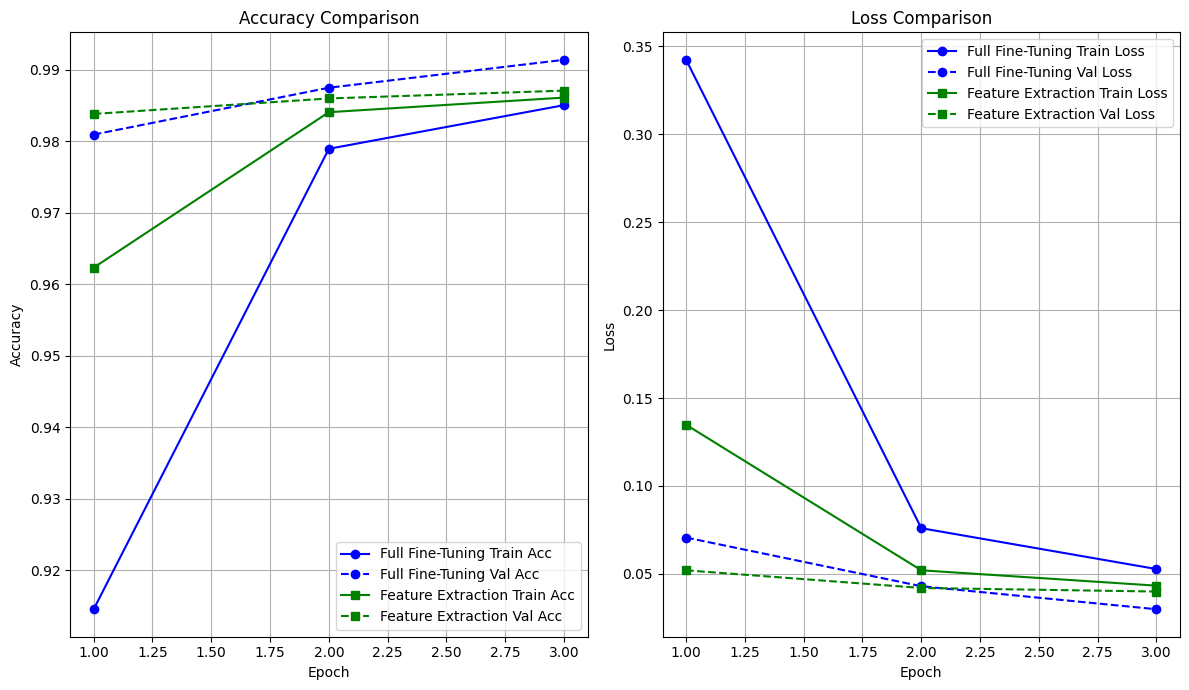

In [ ]:
# 성능 비교 그래프

import matplotlib.pyplot as plt

epochs = range(1, num_epochs_mnist + 1)

plt.figure(figsize=(12, 7))

# Accuracy 비교
plt.subplot(1, 2, 1)
plt.plot(epochs, ft_train_accs, '-o', c = 'b', label = 'Full Fine-Tuning Train Acc')
plt.plot(epochs, ft_val_accs, 'o--', c = 'b', label = 'Full Fine-Tuning Val Acc')
plt.plot(epochs, fe_train_accs, 's-', c = 'g', label = 'Feature Extraction Train Acc')
plt.plot(epochs, fe_val_accs, 's--', c = 'g', label = 'Feature Extraction Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, ft_train_losses, '-o', c = 'b', label = 'Full Fine-Tuning Train Loss')
plt.plot(epochs, ft_val_losses, 'o--', c = 'b', label = 'Full Fine-Tuning Val Loss')
plt.plot(epochs, fe_train_losses, 's-', c = 'g', label = 'Feature Extraction Train Loss')
plt.plot(epochs, fe_val_losses, 's--', c = 'g', label = 'Feature Extraction Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()